In [1]:
import numpy as np
import pickle
import pandas as pd
from loguru import logger
import matplotlib.pyplot as plt


In [2]:
test_flows = pd.read_csv('./interm/unsw_nb15_processed_test.csv')

In [3]:
len(test_flows)

448587

In [4]:
metrics_dir = './interm/xAI/GNNE_20260309_132324/experiment.pkl'
with open(metrics_dir, 'rb') as f:
	explainability_report = pickle.load(f)

In [5]:
explainability_report.keys()

dict_keys(['meta', 'description', 'results'])

In [6]:
explainability_report['meta'].keys(), explainability_report['results'].keys(), 

(dict_keys(['args', 'model_dir', 'test_f', 'metrics_output_dir']),
 dict_keys(['mask', 'losses', 'mask_regularization']))

In [7]:
explainability_report['results']['mask']

tensor([0.2665, 0.2665, 0.2665,  ..., 0.2665, 0.3172, 0.2665],
       requires_grad=True)

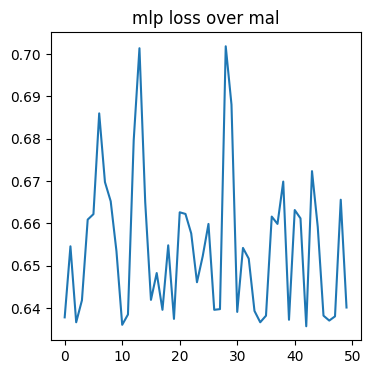

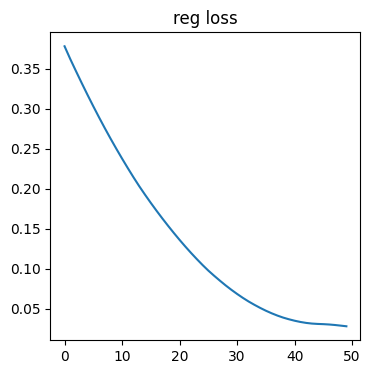

In [8]:
plt.figure(figsize=(4,4))
losses, reg_losses = explainability_report['results']['losses'], explainability_report['results']['mask_regularization']

plt.plot([l - r for l,r in zip(losses, reg_losses)])
plt.title('mlp loss over mal')
plt.show()

plt.figure(figsize=(4,4))
plt.plot(reg_losses)
plt.title('reg loss')
plt.show()

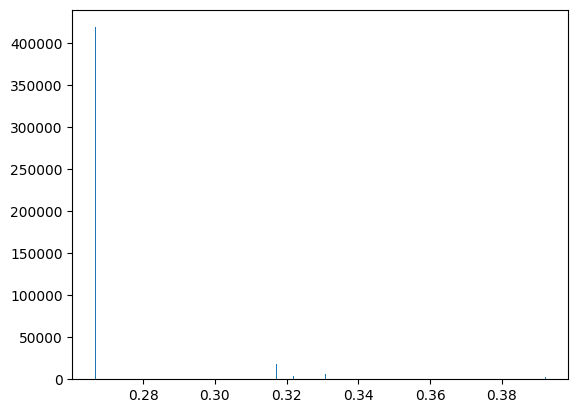

In [9]:
mask = explainability_report['results']['mask'].detach().numpy()
plt.hist(mask, bins=500)
plt.show()

In [10]:
import pickle
from pathlib import Path
from EGraphSAGE import EGraphSAGE

with open(Path(explainability_report['meta']['model_dir']), 'rb')as f:
	model = pickle.load(f)


c:\working\xai_gnn_nids_hdr1\venv311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
from ML_utils import graph_encode, fidelities
import torch

# convert test_flows Attack to binary
test_flows["Attack"] = torch.Tensor(
	(test_flows["Attack"] != "Benign").astype(float).values
).float()

G, _ = graph_encode(test_flows, edge_cols=['src','dst'], linegraph=False, target_col='Attack')

C:\Users\joelh\AppData\Local\Temp\ipykernel_20196\2677428937.py:5: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ..\torch\csrc\utils\tensor_numpy.cpp:212.)
  test_flows["Attack"] = torch.Tensor(


Evaluating masks at spasities: 100%|██████████| 20/20 [00:08<00:00,  2.41it/s]


fp, fm, T


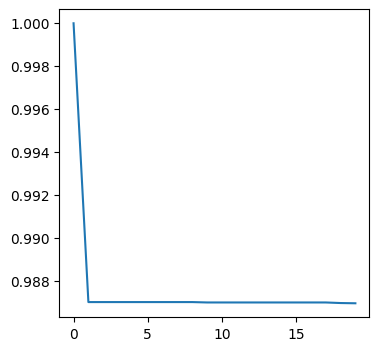

In [ ]:
sparsities=np.arange(0, 0.4, 0.02)
from tqdm import tqdm

y_pred, _ = model.forward(
	G.edge_attr,
	G.edge_index,
)

fps, fms, threshes = [], [], []
for s in tqdm(sparsities, desc=f"Evaluating masks at spasities"):
	threshold = np.percentile(mask, s * 100)

	# can use non differnetiable threshholding here
	binary_edge_mask = torch.FloatTensor(mask > threshold)
	masked_edge_attr = G.edge_attr * binary_edge_mask.unsqueeze(1)
	masked_y_pred, _ = model.forward(
		masked_edge_attr,
		G.edge_index,
	)

	binary_masked_y_pred = (masked_y_pred > 0.5).float()
	binary_y_pred = (y_pred > 0.5).float()
	fp, fm = fidelities(
		y_pred=binary_y_pred,
		y_mask=binary_masked_y_pred,
		y_imask=1 - binary_masked_y_pred,
		y=G.y,
	)

	fps.append(fp)
	fms.append(fm)
	threshes.append(threshes)


print('fp, fm, T')
plt.figure(figsize=(4,4)); plt.plot(fps); plt.show()

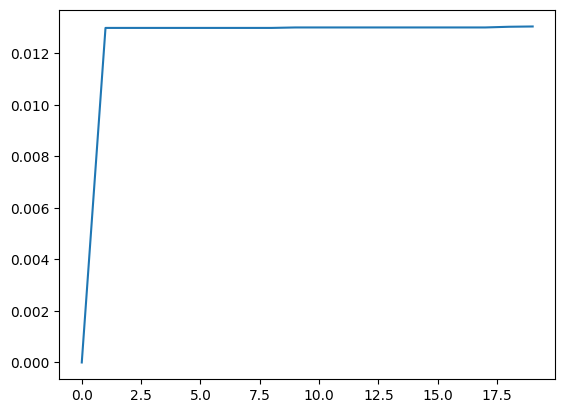

In [15]:
plt.plot(fms)

In [ ]:
# either not training
# or entirely reliant on topology